<a href="https://colab.research.google.com/github/krishthapa-portfolio/Krish_INFO4670_Fall2026/blob/main/Assignment3_AssociationRuleMining_Template.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 3 — Association Rule Mining

**Dataset:** `bread_basket.csv` (11569 transactions)

Fill in the short answer cells and run the code cells. This notebook generates the required tables and figures.

**Sections:**
1. Setup & Data Load
2. EDA (a–e)
3. Frequent Itemset Mining (FP-Growth)
4. Association Rules + Report Table
5. Rule Subgraph (Bread, Coffee, Cake, Tea)
6. Interpretation Prompt


## 1) Setup & Data Load (10 pts)
- Place `bread_basket.csv` in the same folder as this notebook **or** update the path below.
- Needed packages: `pandas`, `matplotlib`, `mlxtend`, `networkx` (for the small graph).
- If a package is missing, run the `pip install` cell.

In [14]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", message=".*utcnow.*")

# !pip install pandas matplotlib mlxtend networkx

import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from mlxtend.frequent_patterns import fpgrowth, association_rules

df = pd.read_csv("bread_basket.csv")
print("Shape:", df.shape)
print("Unique transactions:", df["transaction"].nunique())
print("Unique items:", df["item"].nunique())
df.head()

Shape: (20507, 6)
Unique transactions: 9465
Unique items: 94


,transaction,item,date_time,time,period_day,weekday_weekend
0,1,Bread,30/10/2016,9:58,morning,weekend
1,2,Scandinavian,30/10/2016,10:05,morning,weekend
2,2,Scandinavian,30/10/2016,10:05,morning,weekend
3,3,Hot chocolate,30/10/2016,10:07,morning,weekend
4,3,Jam,30/10/2016,10:07,morning,weekend


## 2) EDA (a–e) (30 pts)
### a) List variables and their dtypes (5 pts)

In [13]:
print(df.dtypes)
print()
print("Missing values per column:")
print(df.isna().sum())

transaction         int64
item               object
date_time          object
time               object
period_day         object
weekday_weekend    object
dtype: object

Missing values per column:
transaction        0
item               0
date_time          0
time               0
period_day         0
weekday_weekend    0
dtype: int64


### b) "Statistics" overview (5 pts)
Use `describe(include='all')` as a stand‑in for Statistics.

In [15]:
df.describe(include='all')

,transaction,item,date_time,time,period_day,weekday_weekend
count,20507.000000,20507,20507,20507,20507,20507
unique,NaN,94,159,1255,4,2
top,NaN,Coffee,2017-02-04,11:06,afternoon,weekday
freq,NaN,5471,292,52,11569,12807
mean,4976.202370,NaN,NaN,NaN,NaN,NaN
std,2796.203001,NaN,NaN,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN,NaN,NaN
25%,2552.000000,NaN,NaN,NaN,NaN,NaN
50%,5137.000000,NaN,NaN,NaN,NaN,NaN
75%,7357.000000,NaN,NaN,NaN,NaN,NaN


### c) Bar plot — count of **unique transactions per item** (10 pts)
Set the subtitle to your **FirstName LastName**.

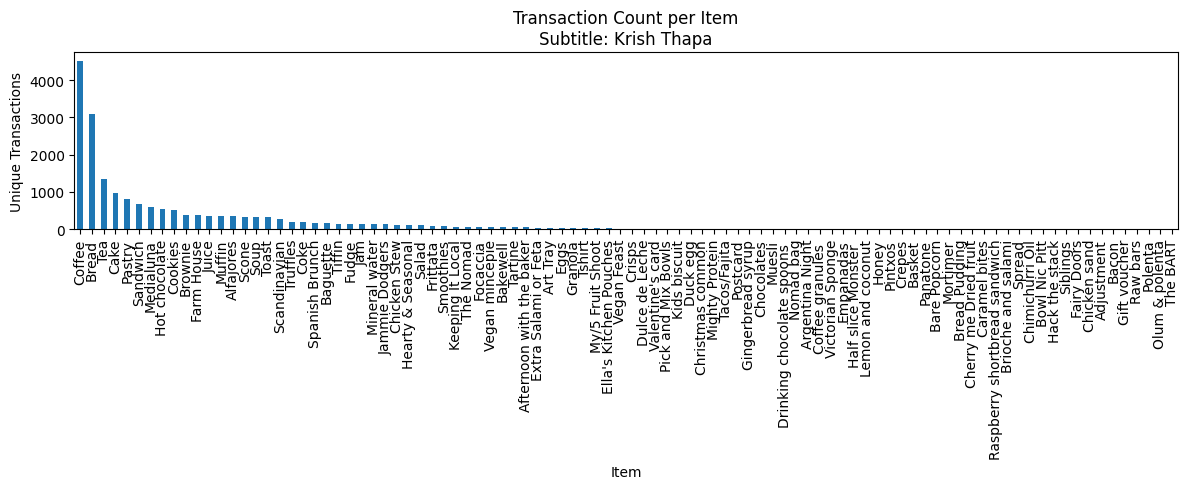

In [16]:
# c) Bar plot of transaction counts per item
subtitle = "Krish Thapa"
item_counts = (df.groupby("item")["transaction"].nunique()
                 .sort_values(ascending=False))

ax = item_counts.plot(kind='bar', figsize=(12,5))
plt.title(f"Transaction Count per Item\nSubtitle: {subtitle}")
plt.xlabel("Item"); plt.ylabel("Unique Transactions")
plt.tight_layout()
plt.show()

### d) Report counts for Coffee, Tea, Alfajores, Juice, and Chicken Stew (10 pts)

In [17]:
items_of_interest = ["Coffee", "Tea", "Alfajores", "Juice", "Chicken Stew"]
counts_d = item_counts.loc[items_of_interest].rename("unique_transactions").to_frame()
counts_d

,unique_transactions
item,
Coffee,4528
Tea,1350
Alfajores,344
Juice,365
Chicken Stew,123


## 3) Frequent Itemset Mining with FP‑Growth (min_support = 0.02) (20 pts)
We pivot the data to a **transaction × item** one‑hot table (boolean), then run FP‑Growth.

In [18]:
# transaction x item one-hot table (True if the item is in the basket)
basket = pd.crosstab(df["transaction"], df["item"]).gt(0)
print("Basket shape:", basket.shape)

frequent_itemsets = fpgrowth(basket, min_support=0.02, use_colnames=True)
frequent_itemsets["length"] = frequent_itemsets["itemsets"].apply(len)
frequent_itemsets = frequent_itemsets.sort_values("support", ascending=False).reset_index(drop=True)

print("Number of frequent itemsets:", len(frequent_itemsets))
frequent_itemsets

Basket shape: (9465, 94)
Number of frequent itemsets: 33


,support,itemsets,length
0,0.478394,(Coffee),1
1,0.327205,(Bread),1
2,0.142631,(Tea),1
3,0.103856,(Cake),1
4,0.090016,"(Bread, Coffee)",2
5,0.086107,(Pastry),1
6,0.071844,(Sandwich),1
7,0.061807,(Medialuna),1
8,0.058320,(Hot chocolate),1
9,0.054728,"(Cake, Coffee)",2


## 4) Association Rules + Report Table (30 pts)
(metric = confidence, min_threshold = ?) Please find a suitable min_threshold

In [21]:
# Checking how many rules different confidence thresholds give
for t in [0.2, 0.3, 0.4, 0.5, 0.6]:
    n = len(association_rules(frequent_itemsets, metric="confidence", min_threshold=t))
    print(f"min_threshold={t}: {n} rules")

# 0.3 keeps a manageable set of rules
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.3)

report = rules[["antecedents", "consequents", "support", "confidence", "lift"]].copy()
report["antecedents"] = report["antecedents"].apply(lambda s: ", ".join(sorted(s)))
report["consequents"] = report["consequents"].apply(lambda s: ", ".join(sorted(s)))
report = report.sort_values("lift", ascending=False).reset_index(drop=True)
report[["support", "confidence", "lift"]] = report[["support", "confidence", "lift"]].round(4)
report

min_threshold=0.2: 13 rules
min_threshold=0.3: 10 rules
min_threshold=0.4: 8 rules
min_threshold=0.5: 8 rules
min_threshold=0.6: 1 rules


,antecedents,consequents,support,confidence,lift
0,Toast,Coffee,0.0237,0.7044,1.4724
1,Medialuna,Coffee,0.0352,0.5692,1.1899
2,Pastry,Coffee,0.0475,0.5521,1.1542
3,Juice,Coffee,0.0206,0.5342,1.1167
4,Sandwich,Coffee,0.0382,0.5324,1.1128
5,Cake,Coffee,0.0547,0.5270,1.1015
6,Cookies,Coffee,0.0282,0.5184,1.0837
7,Hot chocolate,Coffee,0.0296,0.5072,1.0603
8,Pastry,Bread,0.0292,0.3387,1.0350
9,Tea,Coffee,0.0499,0.3496,0.7308


## 5) Rule Subgraph (Bread, Coffee, Cake, Tea)
Rules whose antecedent and consequent items are all in {Bread, Coffee, Cake, Tea}. Edges are labeled with confidence / lift.

   antecedents consequents  support  confidence    lift
0      (Bread)    (Coffee)   0.0900      0.2751  0.5751
1     (Coffee)     (Bread)   0.0900      0.1882  0.5751
2       (Cake)    (Coffee)   0.0547      0.5270  1.1015
3     (Coffee)      (Cake)   0.0547      0.1144  1.1015
4        (Tea)    (Coffee)   0.0499      0.3496  0.7308
5     (Coffee)       (Tea)   0.0499      0.1042  0.7308
12       (Tea)     (Bread)   0.0281      0.1970  0.6022
13       (Tea)      (Cake)   0.0238      0.1667  1.6048
14      (Cake)       (Tea)   0.0238      0.2289  1.6048
16      (Cake)     (Bread)   0.0233      0.2248  0.6871


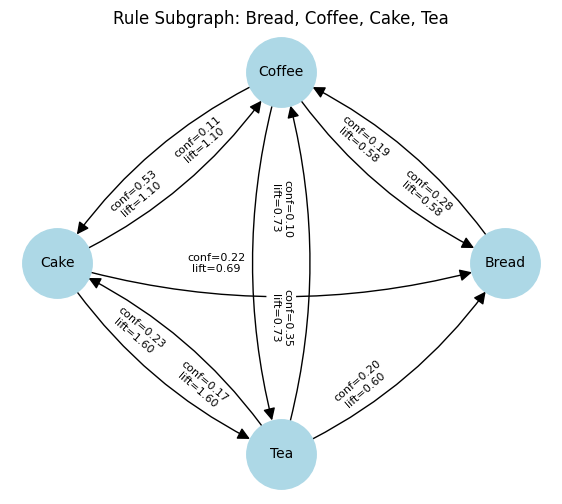

In [20]:
focus = {"Bread", "Coffee", "Cake", "Tea"}

# lower confidence threshold here so the focus items have rules to show
all_rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.1)
sub = all_rules[all_rules.apply(lambda r: set(r["antecedents"]) | set(r["consequents"]) <= focus, axis=1)]
print(sub[["antecedents", "consequents", "support", "confidence", "lift"]].round(4))

G = nx.DiGraph()
for _, r in sub.iterrows():
    a = ", ".join(sorted(r["antecedents"]))
    c = ", ".join(sorted(r["consequents"]))
    G.add_edge(a, c, label=f"conf={r['confidence']:.2f}\nlift={r['lift']:.2f}")

plt.figure(figsize=(7, 6))
pos = nx.circular_layout(G)
nx.draw_networkx_nodes(G, pos, node_size=2500, node_color="lightblue")
nx.draw_networkx_labels(G, pos, font_size=10)
nx.draw_networkx_edges(G, pos, arrowstyle="-|>", arrowsize=18, node_size=2500,
                       connectionstyle="arc3,rad=0.15")
nx.draw_networkx_edge_labels(G, pos, edge_labels=nx.get_edge_attributes(G, "label"),
                             font_size=8, label_pos=0.35)
plt.title("Rule Subgraph: Bread, Coffee, Cake, Tea")
plt.axis("off")
plt.show()

## 6) Interpretation (10 pts)
**Interpret the rule `{Coffee, Cake} ⇒ {Bread}` in plain English.**

- **Support**: What fraction of *all* transactions contain Coffee, Cake, and Bread together?
- **Confidence**: Among baskets with Coffee and Cake, what share also include Bread?
- **Lift > 1** implies positive association; comment on practical meaning.

*Your notes:*

- **Support ≈ 0.010:** Only about 1% of all transactions (95 of 9,465) contain Coffee, Cake, and Bread together. That is below the 0.02 support cutoff, which is why this rule doesn't show up in the FP-Growth results.
- **Confidence ≈ 0.18:** Of the 518 baskets that have both Coffee and Cake, about 18% also include Bread.
- **Lift ≈ 0.56:** Lift is **below 1**, so this is actually a *negative* association. Bread shows up in about 33% of all baskets, but only 18% of Coffee + Cake baskets. Customers buying coffee and cake are less likely than average to also buy bread, probably because coffee + cake is already a complete snack, while bread is more of a separate take-home purchase.
- **Practical meaning:** It wouldn't make sense to bundle bread with a coffee + cake deal or put bread promos next to the cake display. Coffee is the item that links most products in this bakery (Toast, Medialuna, Pastry, Cake → Coffee all have lift > 1), so coffee-based pairings are the better promotion targets.

In [22]:
# metrics for {Coffee, Cake} => {Bread}
ab = basket["Coffee"] & basket["Cake"]
abc = ab & basket["Bread"]

support = abc.mean()
confidence = abc.sum() / ab.sum()
lift = confidence / basket["Bread"].mean()

print(f"Transactions with Coffee & Cake: {ab.sum()}")
print(f"Transactions with Coffee, Cake & Bread: {abc.sum()}")
print(f"Support    = {support:.4f}")
print(f"Confidence = {confidence:.4f}")
print(f"Lift       = {lift:.4f}")

Transactions with Coffee & Cake: 518
Transactions with Coffee, Cake & Bread: 95
Support    = 0.0100
Confidence = 0.1834
Lift       = 0.5605


>